In [48]:
import pandas as pd
import numpy as np

In [49]:
# 识别局部异常点（contextual outliers）
def detectar_outliers_contextuales(serie, k=3, alpha=3):
    """
    Detecta outliers tipo 'salto corto' en una serie temporal.
    serie: pd.Series con valores numéricos
    k: ventana de vecinos (antes y después)
    alpha: umbral multiplicador de std
    """
    outliers = []
    for i in range(k, len(serie)-k):
        ventana = pd.concat([serie[i-k:i], serie[i+1:i+k+1]])
        if ventana.isna().all(): 
            outliers.append(False)
            continue
        mediana = ventana.median()
        std = ventana.std() if ventana.std() > 0 else 1e-6
        diff = abs(serie.iloc[i] - mediana)
        outliers.append(diff > alpha * std)
    # 补齐两端
    outliers = [False]*k + outliers + [False]*k
    return pd.Series(outliers, index=serie.index)


In [50]:
#HBOS (Histogram-based Outlier Score) – 全局版
def hbos_global(df, cols, bins=30, epsilon=1e-8, clip_outside=True, return_parts=False):
    """
    HBOS (Histogram-based Outlier Score) – 全局版
    df: DataFrame
    cols: 需要计算的列名列表（数值列）
    bins: 每列的直方图分箱数
    epsilon: 光滑项，避免对数无穷大
    clip_outside: 超出训练范围的值是否clip到边界bin
    return_parts: True时额外返回每列的对数概率分量
    返回:
        scores: pd.Series, HBOS 分数（越大越异常）
        parts(可选): DataFrame, 每列的 -log p_i 分量
    """
    X = df[cols].copy()
    parts = pd.DataFrame(index=X.index, columns=cols, dtype=float)
    # 逐列做直方图
    histos = {}
    for c in cols:
        x = pd.to_numeric(X[c], errors='coerce').dropna()
        counts, edges = np.histogram(x, bins=bins, density=False)
        probs = counts / counts.sum()
        probs = np.maximum(probs, epsilon)     # 光滑
        histos[c] = (probs, edges)
    # 计算每个样本落入的bin概率
    for c in cols:
        probs, edges = histos[c]
        vals = pd.to_numeric(X[c], errors='coerce')
        idx = np.searchsorted(edges, vals, side='right') - 1  # [-1, bins-1]
        # 处理越界
        if clip_outside:
            idx = pd.Series(idx, index=vals.index).clip(lower=0, upper=len(probs)-1)
        else:
            bad_low = idx < 0
            bad_high = idx >= len(probs)
            idx = pd.Series(idx, index=vals.index).where(~(bad_low | bad_high), np.nan)
        p = pd.Series(np.nan, index=X.index, dtype=float)
        ok = idx.notna()
        p.loc[ok] = probs[idx[ok].astype(int)]
        p = p.fillna(epsilon)
        parts[c] = -np.log(p)
    scores = parts.sum(axis=1)
    return (scores, parts) if return_parts else scores

In [51]:
#!pip install scikit-learn

In [52]:
# kNN-based outlier score

from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

def knn_distance_score(df, cols, k=20, use_mean=True, scale=True):
    """
    kNN-based outlier score.
    score = 第k邻居距离 或 k个邻居平均距离（越大越异常）
    """
    X = df[cols].astype(float).values
    if scale:
        X = StandardScaler().fit_transform(X)
    nbrs = NearestNeighbors(n_neighbors=k+1, n_jobs=None).fit(X)
    dists, _ = nbrs.kneighbors(X)                      # dists[:,0] 是到自己的距离=0
    if use_mean:
        score = dists[:, 1:k+1].mean(axis=1)
    else:
        score = dists[:, k]                            # 第k近邻的距离
    return pd.Series(score, index=df.index, name="knn_score")

In [53]:
# 读取描述文件
desc = pd.read_csv('../../Proyecto Herramienta para monitoreo de la calidad de datos/2. Datos/planta_1/planta_1_descripcion.csv')

# 读取数据
df = pd.read_csv('../../df_procesados/df_planta_1_timeseries.csv')

# 初始化标签
df['outlier'] = False
df['anomalo'] = False

# 遍历每个变量，根据描述文件打标签
for _, row in desc.iterrows():
    var = row['name']
    # critical/warning阈值
    cmax = row['critical_max_value'] if not pd.isnull(row['critical_max_value']) else None
    cmin = row['critical_min_value'] if not pd.isnull(row['critical_min_value']) else None
    wmax = row['warning_max_value'] if not pd.isnull(row['warning_max_value']) else None
    wmin = row['warning_min_value'] if not pd.isnull(row['warning_min_value']) else None
    if var in df.columns:
        # outlier标签
        if cmax is not None:
            df.loc[df[var] > cmax, 'outlier'] = True
        if cmin is not None:
            df.loc[df[var] < cmin, 'outlier'] = True
        # anomalo标签
        if wmax is not None:
            df.loc[(df[var] > wmax) & (df['outlier'] == False), 'anomalo'] = True
        if wmin is not None:
            df.loc[(df[var] < wmin) & (df['outlier'] == False), 'anomalo'] = True

df[['timestamp','outlier','anomalo'] + [c for c in df.columns if c not in ['timestamp','outlier','anomalo']]].head(120)

,timestamp,outlier,anomalo,Conductividad DAF,Flujo Parshall 01 entrada a Ecualizador 1,Flujo de envío a DAF,Nivel Ecualizador 1 (Tk 30m3),Nivel Ecualizador 2 (Tk 250m3),Temperatura DAF,pH Clarificado DAF (Tk 80m3),pH Ecualizador 2 (Tk 250m3),pH coagulación entrada DAF,pH entrada a Ecualizador 2 (Tk 250m3),pH salida a Parshall 02,Nivel Clarificado DAF (Tk 80m3),pH entrada a Ecualizador 1,Turbidez salida DAF,pH salida y control Ecualizador 1,planta1_activa
0,2025-05-21T06:29:00-04:00,True,False,500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,2025-05-22T20:31:00-04:00,True,False,42.0,42.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
2,2025-05-22T20:32:00-04:00,True,False,NaN,NaN,42.000000,42.0,42.000000,42.0,NaN,42.0,42.000000,42.000000,NaN,42.000000,42.0,42.000000,42.000000,True
3,2025-05-22T20:41:00-04:00,True,False,42.0,42.000000,42.000000,42.0,42.000000,42.0,42.000000,42.0,42.000000,42.000000,42.000000,42.000000,42.0,42.000000,42.000000,True
4,2025-05-22T20:46:00-04:00,True,False,500.0,5.361979,0.086806,80.0,23.336227,0.0,7.057220,0.0,7.092665,4.702619,11.059029,12.718099,0.0,0.000000,8.627882,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,2025-05-22T23:37:00-04:00,True,False,500.0,4.355035,0.130208,80.0,23.356482,0.0,6.932147,0.0,7.094184,4.682364,8.729052,12.669271,0.0,0.289352,11.385127,False
116,2025-05-22T23:38:00-04:00,True,False,500.0,4.027778,0.141059,80.0,23.344908,0.0,6.955440,0.0,7.091652,4.679832,8.729052,12.682292,0.0,1.012731,8.737154,False
117,2025-05-22T23:40:00-04:00,True,False,500.0,3.851562,0.141059,80.0,23.365162,0.0,6.833912,0.0,7.096716,4.684896,8.735126,12.721354,0.0,0.000000,8.745255,False
118,2025-05-22T23:41:00-04:00,True,False,500.0,3.599826,0.086806,80.0,23.356482,0.0,6.876447,0.0,7.097728,4.687428,8.737154,12.652995,0.0,0.868056,8.747280,False


In [54]:
#第一种基于前后数据检测outlier的方法
# 针对所有数值型变量做contextual outlier
for col in df.select_dtypes(include='number').columns:
    df[f'contextual_outlier_{col}'] = detectar_outliers_contextuales(df[col])

# 显示部分结果
df[[c for c in df.columns if c.startswith('contextual_outlier')]].head(120)

,contextual_outlier_Conductividad DAF,contextual_outlier_Flujo Parshall 01 entrada a Ecualizador 1,contextual_outlier_Flujo de envío a DAF,contextual_outlier_Nivel Ecualizador 1 (Tk 30m3),contextual_outlier_Nivel Ecualizador 2 (Tk 250m3),contextual_outlier_Temperatura DAF,contextual_outlier_pH Clarificado DAF (Tk 80m3),contextual_outlier_pH Ecualizador 2 (Tk 250m3),contextual_outlier_pH coagulación entrada DAF,contextual_outlier_pH entrada a Ecualizador 2 (Tk 250m3),contextual_outlier_pH salida a Parshall 02,contextual_outlier_Nivel Clarificado DAF (Tk 80m3),contextual_outlier_pH entrada a Ecualizador 1,contextual_outlier_Turbidez salida DAF,contextual_outlier_pH salida y control Ecualizador 1
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
116,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
117,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
118,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


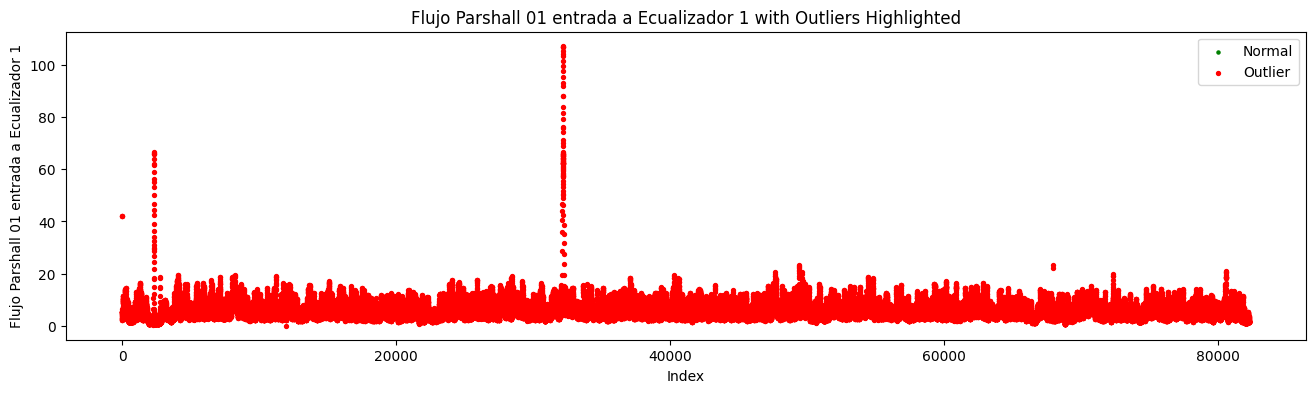


==== CAUDAL ====
Flujo Parshall 01 entrada a Ecualizador 1: outlier=99.92%, anomalo=0.03%, contextual_outlier=0.34%
Flujo de envío a DAF: outlier=99.94%, anomalo=0.03%, contextual_outlier=5.49%

==== NIVEL ====
Nivel Ecualizador 1 (Tk 30m3): outlier=99.95%, anomalo=0.03%, contextual_outlier=0.19%
Nivel Ecualizador 2 (Tk 250m3): outlier=99.98%, anomalo=0.03%, contextual_outlier=2.17%
Nivel Clarificado DAF (Tk 80m3): outlier=100.00%, anomalo=0.03%, contextual_outlier=2.86%
Nivel Clarificado DAF (Tk 80m3): outlier=100.00%, anomalo=0.03%, contextual_outlier=2.86%

==== PH ====
pH Clarificado DAF (Tk 80m3): outlier=100.00%, anomalo=0.02%, contextual_outlier=3.28%
pH Clarificado DAF (Tk 80m3): outlier=100.00%, anomalo=0.02%, contextual_outlier=3.28%
pH Ecualizador 2 (Tk 250m3): outlier=100.00%, anomalo=0.03%, contextual_outlier=0.00%
pH coagulación entrada DAF: outlier=100.00%, anomalo=0.03%, contextual_outlier=2.93%
pH entrada a Ecualizador 2 (Tk 250m3): outlier=100.00%, anomalo=0.03%, con

In [55]:
import matplotlib.pyplot as plt

# 取第一列数据（去掉timestamp，取第一个数值型变量）
first_col = df.columns[2]
y = df[first_col]
x = range(len(y))

# 标记outlier和正常点
outlier_mask = df['outlier']
normal_mask = ~df['outlier']

plt.figure(figsize=(16, 4))
plt.scatter([i for i in x if normal_mask.iloc[i]], y[normal_mask], color='green', s=5, label='Normal')
plt.scatter([i for i in x if outlier_mask.iloc[i]], y[outlier_mask], color='red', s=8, label='Outlier')
plt.title(f'{first_col} with Outliers Highlighted')
plt.xlabel('Index')
plt.ylabel(first_col)
plt.legend()
plt.show()  

# 以类似方式展示其他类型变量的outlier/anomalo/contextual_outlier分布
for var in ['caudal', 'nivel', 'ph', 'turbidez', 'temperatura']:
    # 找到该类型的所有变量名
    vars_tipo = desc.loc[desc['type_var'] == var, 'name']
    print(f"\n==== {var.upper()} ====")
    for v in vars_tipo:
        if v in df.columns:
            outlier_pct = df['outlier'][df[v].notna()].mean() * 100
            anomalo_pct = df['anomalo'][df[v].notna()].mean() * 100
            contextual_col = f'contextual_outlier_{v}'
            contextual_pct = df[contextual_col][df[v].notna()].mean() * 100 if contextual_col in df.columns else None
            print(f"{v}: outlier={outlier_pct:.2f}%, anomalo={anomalo_pct:.2f}%, contextual_outlier={contextual_pct:.2f}%") 

# 显示所有数值型变量的outlier/anomalo/contextual_outlier占比
print("\n==== 各变量异常占比 ====")
for col in df.select_dtypes(include='number').columns:
    outlier_pct = df['outlier'][df[col].notna()].mean() * 100
    anomalo_pct = df['anomalo'][df[col].notna()].mean() * 100
    contextual_col = f'contextual_outlier_{col}'
    contextual_pct = df[contextual_col][df[col].notna()].mean() * 100 if contextual_col in df.columns else None
    print(f"{col}: outlier={outlier_pct:.2f}%, anomalo={anomalo_pct:.2f}%, contextual_outlier={contextual_pct:.2f}%")

In [56]:

# 选择所有数值型列
num_cols2 = df1.select_dtypes(include='number').columns.tolist()

# 用hbos_global检测outlier
hbos_scores2 = hbos_global(df1, num_cols2, bins=30)
thresh2 = hbos_scores2.mean() + 3 * hbos_scores2.std()
df1['outlier'] = hbos_scores2 > thresh2



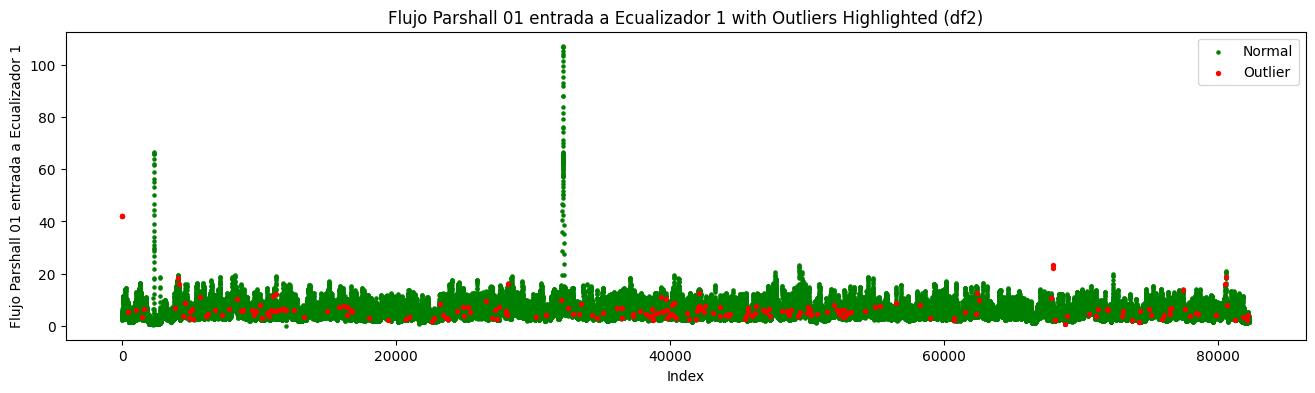


==== df2各变量HBOS outlier占比 ====
Conductividad DAF: outlier=0.28%
Flujo Parshall 01 entrada a Ecualizador 1: outlier=0.25%
Flujo de envío a DAF: outlier=0.23%
Nivel Ecualizador 1 (Tk 30m3): outlier=0.22%
Nivel Ecualizador 2 (Tk 250m3): outlier=0.19%
Temperatura DAF: outlier=0.22%
pH Clarificado DAF (Tk 80m3): outlier=0.15%
pH Ecualizador 2 (Tk 250m3): outlier=0.12%
pH coagulación entrada DAF: outlier=0.15%
pH entrada a Ecualizador 2 (Tk 250m3): outlier=0.15%
pH salida a Parshall 02: outlier=0.17%
Nivel Clarificado DAF (Tk 80m3): outlier=0.17%
pH entrada a Ecualizador 1: outlier=0.15%
Turbidez salida DAF: outlier=0.20%
pH salida y control Ecualizador 1: outlier=0.15%


In [ ]:
# 可视化第一个数值型变量的outlier分布
import matplotlib.pyplot as plt
first_col2 = num_cols2[1] if num_cols2 else None
if first_col2:
    y2 = df1[first_col2]
    x2 = range(len(y2))
    outlier_mask2 = df1['outlier']
    normal_mask2 = ~df1['outlier']
    plt.figure(figsize=(16, 4))
    plt.scatter([i for i in x2 if normal_mask2.iloc[i]], y2[normal_mask2], color='green', s=5, label='Normal')
    plt.scatter([i for i in x2 if outlier_mask2.iloc[i]], y2[outlier_mask2], color='red', s=8, label='Outlier')
    plt.title(f'{first_col2} with Outliers Highlighted (df1)')
    plt.xlabel('Index')
    plt.ylabel(first_col2)
    plt.legend()
    plt.show() 

# 显示df2每个数值型变量被HBOS标记为outlier的占比
print("\n==== df2各变量HBOS outlier占比 ====")
for col in num_cols2:
    pct = df1['outlier'][df1[col].notna()].mean() * 100
    print(f"{col}: outlier={pct:.2f}%")


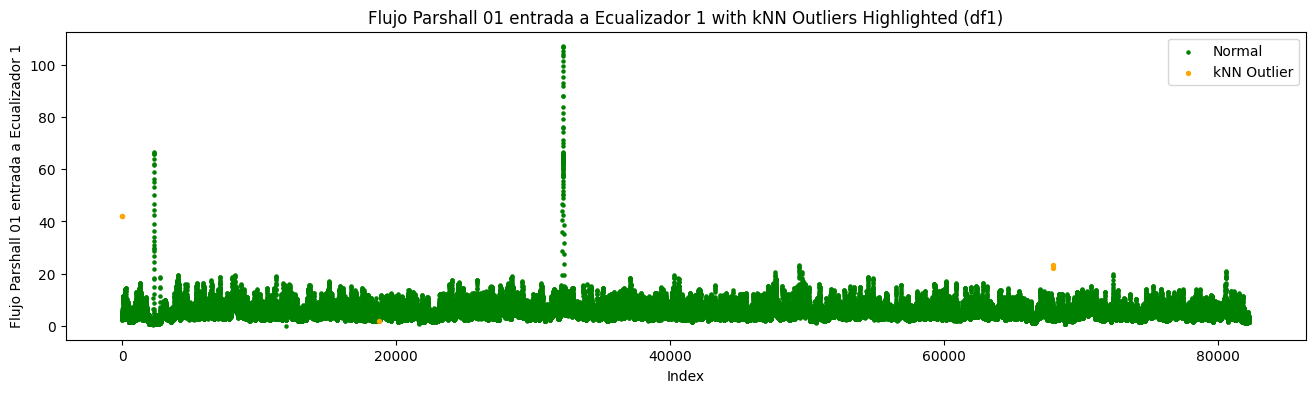


==== df1各变量kNN outlier占比 ====
Conductividad DAF: kNN outlier=0.01%
Flujo Parshall 01 entrada a Ecualizador 1: kNN outlier=0.01%
Flujo de envío a DAF: kNN outlier=0.01%
Nivel Ecualizador 1 (Tk 30m3): kNN outlier=0.01%
Nivel Ecualizador 2 (Tk 250m3): kNN outlier=0.01%
Temperatura DAF: kNN outlier=0.01%
pH Clarificado DAF (Tk 80m3): kNN outlier=0.01%
pH Ecualizador 2 (Tk 250m3): kNN outlier=0.01%
pH coagulación entrada DAF: kNN outlier=0.01%
pH entrada a Ecualizador 2 (Tk 250m3): kNN outlier=0.01%
pH salida a Parshall 02: kNN outlier=0.01%
Nivel Clarificado DAF (Tk 80m3): kNN outlier=0.01%
pH entrada a Ecualizador 1: kNN outlier=0.01%
Turbidez salida DAF: kNN outlier=0.01%
pH salida y control Ecualizador 1: kNN outlier=0.01%


In [59]:
# 用knn_distance_score检测outlier（先填充缺失值）
k = 20  # 可调整
df1_filled = df1.copy()
df1_filled[num_cols2] = df1_filled[num_cols2].fillna(df1[num_cols2].mean())
knn_scores2 = knn_distance_score(df1_filled, num_cols2, k=k, use_mean=True, scale=True)
thresh_knn2 = knn_scores2.mean() + 3 * knn_scores2.std()
df1['knn_outlier'] = knn_scores2 > thresh_knn2

# 可视化第一个数值型变量的knn_outlier分布
first_col2 = num_cols2[1] if num_cols2 else None
if first_col2:
    y2 = df1[first_col2]
    x2 = range(len(y2))
    knn_outlier_mask2 = df1['knn_outlier']
    normal_mask2 = ~df1['knn_outlier']
    plt.figure(figsize=(16, 4))
    plt.scatter([i for i in x2 if normal_mask2.iloc[i]], y2[normal_mask2], color='green', s=5, label='Normal')
    plt.scatter([i for i in x2 if knn_outlier_mask2.iloc[i]], y2[knn_outlier_mask2], color='orange', s=8, label='kNN Outlier')
    plt.title(f'{first_col2} with kNN Outliers Highlighted (df1)')
    plt.xlabel('Index')
    plt.ylabel(first_col2)
    plt.legend()
    plt.show()

# 显示df2每个数值型变量被kNN标记为outlier的占比
print("\n==== df1各变量kNN outlier占比 ====")
for col in num_cols2:
    pct = df1['knn_outlier'][df1[col].notna()].mean() * 100
    print(f"{col}: kNN outlier={pct:.2f}%")

In [ ]:
#cd打印当前文件夹
import os
os.getcwd()

'e:\\学习使我快乐\\2025年下学期\\proyecto_grado\\proyecto\\timeseries-labeler-main\\timeseries-labeler-main'


# 合并手动标记的数据
# 读取原始数据
df = pd.read_csv(r'e:\学习使我快乐\2025年下学期\proyecto_grado\proyecto\Proyecto Herramienta para monitoreo de la calidad de datos\2. Datos\planta_2\planta_2_datos.csv')

# 转换时间格式
df['timestamp'] = pd.to_datetime(df['date_time']).dt.strftime('%Y-%m-%dT%H:%M:%S-04:00')

# 替换原有时间列
df = df.drop(columns=['date_time'])
df = df[['timestamp'] + [col for col in df.columns if col != 'timestamp']]
# 原本的df split按照行总行数分割为两个部分
df_part1 = df.iloc[:len(df)//2].reset_index(drop=True)
df_part2 = df.iloc[len(df)//2:].reset_index(drop=True)
# 保存为新文件
df_part1.to_csv(r'E:\学习使我快乐\2025年下学期\proyecto_grado\proyecto\df_procesados\df_planta_2_timeseries_part1.csv', index=False)
df_part2.to_csv(r'E:\学习使我快乐\2025年下学期\proyecto_grado\proyecto\df_procesados\df_planta_2_timeseries_part2.csv', index=False)

df_2_part1 = pd.read_csv(r'E:\学习使我快乐\2025年下学期\proyecto_grado\proyecto\df_procesados\planta2p1_data_etiquetada_long.csv')
df_2_part2 = pd.read_csv(r'E:\学习使我快乐\2025年下学期\proyecto_grado\proyecto\df_procesados\planta2p2_data_etiquetada_long.csv')

df_2 = pd.concat([df_2_part1, df_2_part2], ignore_index=True)
df_2.to_csv(r'E:\学习使我快乐\2025年下学期\proyecto_grado\proyecto\df_procesados\planta2_data_etiquetada_long.csv', index=False)

df_2_part1_wide = pd.read_csv(r'E:\学习使我快乐\2025年下学期\proyecto_grado\proyecto\df_procesados\planta2p1_data_etiquetada_wide.csv')
df_2_part2_wide = pd.read_csv(r'E:\学习使我快乐\2025年下学期\proyecto_grado\proyecto\df_procesados\planta2p2_data_etiquetada_wide.csv')

df_2_wide = pd.concat([df_2_part1_wide, df_2_part2_wide], ignore_index=True)
df_2_wide.to_csv(r'E:\学习使我快乐\2025年下学期\proyecto_grado\proyecto\df_procesados\planta2_data_etiquetada_wide.csv', index=False)

In [ ]:
#类似的操作对planta3进行预处理
# 读取原始数据
df3 = pd.read_csv(r'e:\学习使我快乐\2025年下学期\proyecto_grado\proyecto\Proyecto Herramienta para monitoreo de la calidad de datos\2. Datos\planta_3\planta_3_datos.csv')
# 转换时间格式
df3['timestamp'] = pd.to_datetime(df3['date_time']).dt.strftime('%Y-%m-%dT%H:%M:%S-04:00')
# 替换原有时间列
df3 = df3.drop(columns=['date_time'])
df3 = df3[['timestamp'] + [col for col in df3.columns if col != 'timestamp']]
# 保存为新文件
df3.to_csv(r'E:\学习使我快乐\2025年下学期\proyecto_grado\proyecto\df_procesados\df_planta_3_timeseries.csv', index=False)

In [ ]:
print(df1.columns.tolist())

['timestamp', 'Conductividad DAF', 'Flujo Parshall 01 entrada a Ecualizador 1', 'Flujo de envío a DAF', 'Nivel Ecualizador 1 (Tk 30m3)', 'Nivel Ecualizador 2 (Tk 250m3)', 'Temperatura DAF', 'pH Clarificado DAF (Tk 80m3)', 'pH Ecualizador 2 (Tk 250m3)', 'pH coagulación entrada DAF', 'pH entrada a Ecualizador 2 (Tk 250m3)', 'pH salida a Parshall 02', 'Nivel Clarificado DAF (Tk 80m3)', 'pH entrada a Ecualizador 1', 'Turbidez salida DAF', 'pH salida y control Ecualizador 1', 'planta1_activa']


In [ ]:
# 读取手动标记的long形式数据（以时间戳为id，最后一列为outlier标签）
df_manual1 = pd.read_csv(r'E:\学习使我快乐\2025年下学期\proyecto_grado\proyecto\df_procesados\planta2_data_etiquetada_long.csv')

df_manual1.head()

,timestamp,variable,valor,etiqueta
0,2024-08-13T02:08:00Z,Flujo Cámara de contacto 1,1942.00,outlier
1,2024-08-13T02:09:00Z,Flujo Cámara de contacto 1,1882.00,outlier
2,2024-08-13T02:10:00Z,Flujo Cámara de contacto 1,1906.50,outlier
3,2024-08-13T02:11:00Z,Flujo Cámara de contacto 1,2009.00,outlier
4,2024-08-15T18:33:00Z,Flujo Salida de Lodo Sedimentador Secundario 3,30.55,outlier


In [ ]:

df1['manual_etiqueta'] = df1['timestamp'].isin(df_manual1['timestamp'])
df1.head()

,timestamp,Conductividad DAF,Flujo Parshall 01 entrada a Ecualizador 1,Flujo de envío a DAF,Nivel Ecualizador 1 (Tk 30m3),Nivel Ecualizador 2 (Tk 250m3),Temperatura DAF,pH Clarificado DAF (Tk 80m3),pH Ecualizador 2 (Tk 250m3),pH coagulación entrada DAF,pH entrada a Ecualizador 2 (Tk 250m3),pH salida a Parshall 02,Nivel Clarificado DAF (Tk 80m3),pH entrada a Ecualizador 1,Turbidez salida DAF,pH salida y control Ecualizador 1,planta1_activa,outlier,knn_outlier,manual_etiqueta
0,2025-05-21T06:29:00-04:00,500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,False,False
1,2025-05-22T20:31:00-04:00,42.0,42.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,True,False,False
2,2025-05-22T20:32:00-04:00,NaN,NaN,42.000000,42.0,42.000000,42.0,NaN,42.0,42.000000,42.000000,NaN,42.000000,42.0,42.0,42.000000,True,True,True,False
3,2025-05-22T20:41:00-04:00,42.0,42.000000,42.000000,42.0,42.000000,42.0,42.00000,42.0,42.000000,42.000000,42.000000,42.000000,42.0,42.0,42.000000,True,True,True,False
4,2025-05-22T20:46:00-04:00,500.0,5.361979,0.086806,80.0,23.336227,0.0,7.05722,0.0,7.092665,4.702619,11.059029,12.718099,0.0,0.0,8.627882,False,False,False,False


In [ ]:
#可视化df1,标记manual_etiqueta的点为红色，etiqueta为黄色，其他则为绿色

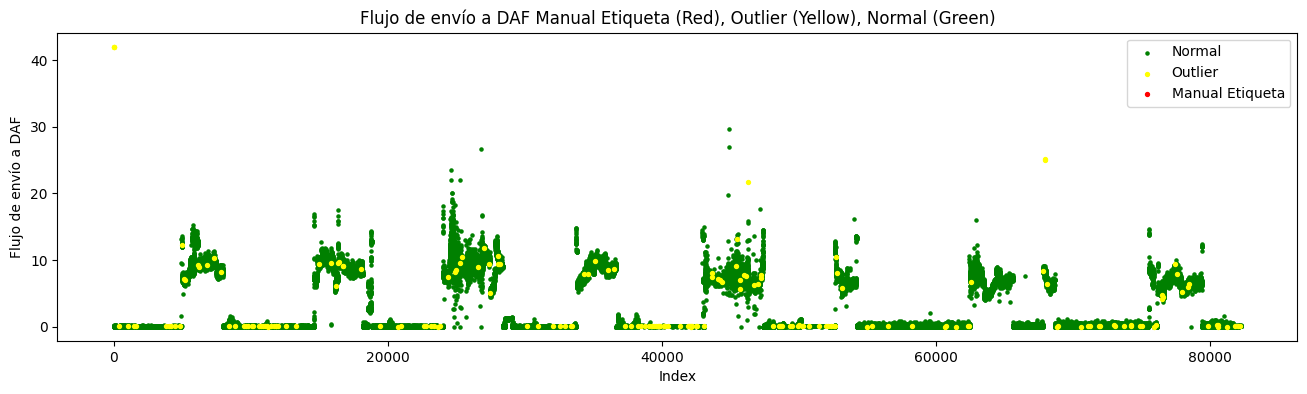

In [63]:
# 可视化df1，manual_etiqueta为红色，outlier为黄色，其他为绿色
first_col = df1.select_dtypes(include='number').columns[2]
y = df1[first_col]
x = range(len(y))
manual_mask = df1['manual_etiqueta']
outlier_mask = df1['outlier'] & (~manual_mask)
normal_mask = ~(manual_mask | outlier_mask)
import matplotlib.pyplot as plt
plt.figure(figsize=(16, 4))
plt.scatter([i for i in x if normal_mask.iloc[i]], y[normal_mask], color='green', s=5, label='Normal')
plt.scatter([i for i in x if outlier_mask.iloc[i]], y[outlier_mask], color='yellow', s=8, label='Outlier')
plt.scatter([i for i in x if manual_mask.iloc[i]], y[manual_mask], color='red', s=8, label='Manual Etiqueta')
plt.title(f'{first_col} Manual Etiqueta (Red), Outlier (Yellow), Normal (Green)')
plt.xlabel('Index')
plt.ylabel(first_col)
plt.legend()
plt.show()

In [64]:
#df1 manual_etiqueta占比
pct_manual = df1['manual_etiqueta'].mean() * 100
print(f"df1 manual_etiqueta占比: {pct_manual:.2f}%")

df1 manual_etiqueta占比: 0.00%
